In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [2]:
plt.style.use("default")

In [3]:
# Configs
CSV_PATH = "predictions_test_annotated.csv"
OUTDIR = "post_eval_outputs"
os.makedirs(OUTDIR, exist_ok=True)

TIME_COL = "time"
PID_COL = "patient_idx"
YTRUE_COL = "y_true"

PS_COL = "p_S"
PD_COL = "p_D"

# load
df = pd.read_csv(CSV_PATH)
df = df.sort_values([PID_COL, TIME_COL]).reset_index(drop=True)

print("Rows:", len(df))
print("Patients:", df[PID_COL].nunique())
print("Columns:", df.columns[:20].tolist(), "...")

Rows: 37397
Patients: 5856
Columns: ['_orig_idx', 'patient_idx', 'time', 'y_true', 'y_pred', 'p_H', 'p_M', 'p_S', 'p_D', 'STATE', 'NEXT_STATE', 'AGE_GROUP', 'attn_REGION', 'attn_MARITAL_STATUS', 'attn_RAGENDER', 'attn_RARACEM', 'attn_RAHISPAN', 'attn_RAEDUC'] ...


In [4]:
# color assignments
STATE_COLORS = {
    "H": "#4c72b0",  # blue
    "M": "#55a868",  # green
    "S": "#c44e52",  # red
    "D": "#8172b3",  # purple
}
SEV_COLOR = STATE_COLORS["S"]

In [5]:
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42   # embed TrueType fonts (good for LaTeX/publishers)
mpl.rcParams["ps.fonttype"]  = 42
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["savefig.pad_inches"] = 0.02


Risk band stability summary:


,endpoint,n_transitions,pct_same_or_adjacent,pct_large_jump_ge3,jump_hist
0,Severe,31541,0.816778,0.082432,"{0: 13979, 1: 11783, 2: 3179, 3: 1092, 4: 601,..."
1,Death,31541,0.849815,0.044894,"{0: 14264, 1: 12540, 2: 3321, 3: 936, 4: 325, ..."


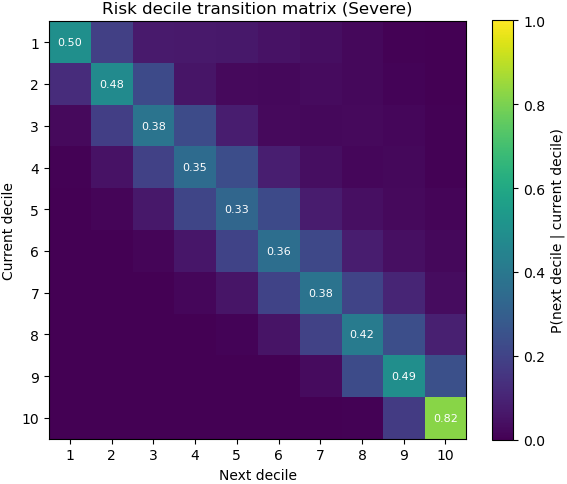

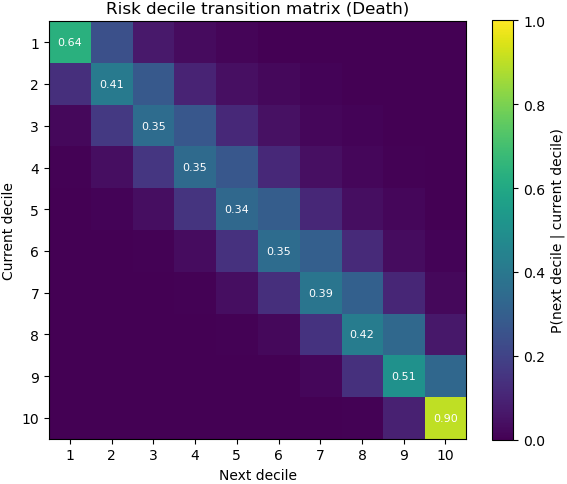

In [6]:
# Risk band stability (deciles)

def assign_global_deciles(df, prob_col, label_col):
    """
    Global deciles across the full test set (not wave-specific).
    0=lowest risk, 9=highest risk.
    """
    out = df.copy()
    out[label_col] = pd.qcut(out[prob_col], 10, labels=False, duplicates="drop")
    out[label_col] = out[label_col].astype(int)
    return out

df = assign_global_deciles(df, PS_COL, "decile_S")
df = assign_global_deciles(df, PD_COL, "decile_D")


def stability_stats(df, decile_col):
    """
    Computes:
      - pct staying in same/adjacent decile next wave (|Δ|<=1)
      - pct making large jumps (|Δ|>=3)
      - distribution of absolute jumps
    """
    abs_jumps = []

    for pid, g in df.groupby(PID_COL, sort=False):
        g = g.sort_values(TIME_COL)
        dec = g[decile_col].values
        if len(dec) < 2:
            continue
        abs_jumps.extend(np.abs(np.diff(dec)).tolist())

    abs_jumps = np.array(abs_jumps, dtype=int)
    if abs_jumps.size == 0:
        return {
            "n_transitions": 0,
            "pct_same_or_adjacent": np.nan,
            "pct_large_jump_ge3": np.nan,
            "jump_hist": {}
        }

    return {
        "n_transitions": int(abs_jumps.size),
        "pct_same_or_adjacent": float((abs_jumps <= 1).mean()),
        "pct_large_jump_ge3": float((abs_jumps >= 3).mean()),
        "jump_hist": {int(k): int(v) for k, v in zip(*np.unique(abs_jumps, return_counts=True))}
    }

stab_S = stability_stats(df, "decile_S")
stab_D = stability_stats(df, "decile_D")

stability_table = pd.DataFrame([
    {"endpoint": "Severe", **stab_S},
    {"endpoint": "Death",  **stab_D},
])
stability_table.to_csv(os.path.join(OUTDIR, "risk_band_stability_summary.csv"), index=False)

print("\nRisk band stability summary:")
display(stability_table)


# Risk band transition matrix
def transition_matrix(df, decile_col, n_bins=10):
    mat = np.zeros((n_bins, n_bins), dtype=float)
    for pid, g in df.groupby(PID_COL, sort=False):
        g = g.sort_values(TIME_COL)
        dec = g[decile_col].values
        if len(dec) < 2:
            continue
        for a, b in zip(dec[:-1], dec[1:]):
            mat[a, b] += 1.0
    # row-normalize
    row_sums = mat.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        mat = np.where(row_sums > 0, mat / row_sums, 0.0)
    return mat

mat_S = transition_matrix(df, "decile_S", n_bins=10)
mat_D = transition_matrix(df, "decile_D", n_bins=10)

np.save(os.path.join(OUTDIR, "risk_decile_transition_matrix_severe.npy"), mat_S)
np.save(os.path.join(OUTDIR, "risk_decile_transition_matrix_death.npy"), mat_D)

def plot_heatmap(mat, title, outpath_pdf, outpath_png=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(mat, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P(next decile | current decile)")

    # Label deciles 1..10 (but indices are 0..9)
    deciles = np.arange(1, 11)
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels(deciles)
    ax.set_yticklabels(deciles)

    ax.set_xlabel("Next decile")
    ax.set_ylabel("Current decile")
    ax.set_title(title)

    # Annotate diagonal persistence
    for i in range(10):
        val = mat[i, i]
        if val > 0.3:
            ax.text(i, i, f"{val:.2f}", ha="center", va="center",
                    color="white", fontsize=8)

    fig.tight_layout()

    fig.savefig(outpath_pdf) 

    if outpath_png is not None:
        fig.savefig(outpath_png, dpi=600)

    plt.show()
    plt.close(fig)

plot_heatmap(
    mat_S,
    "Risk decile transition matrix (Severe)",
    os.path.join(OUTDIR, "risk_decile_transition_severe.pdf"),
    os.path.join(OUTDIR, "risk_decile_transition_severe.png"),
)

plot_heatmap(
    mat_D,
    "Risk decile transition matrix (Death)",
    os.path.join(OUTDIR, "risk_decile_transition_death.pdf"),
    os.path.join(OUTDIR, "risk_decile_transition_death.png"),
)

{'TP_Severe': 7214, 'TP_Death': 22574, 'FP_Severe': 35262}


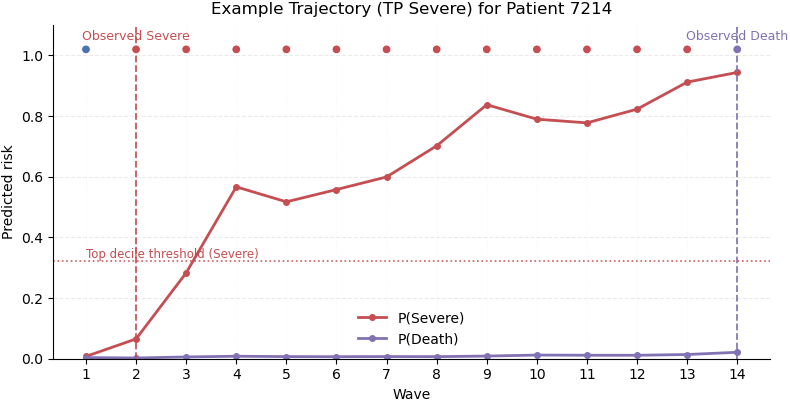

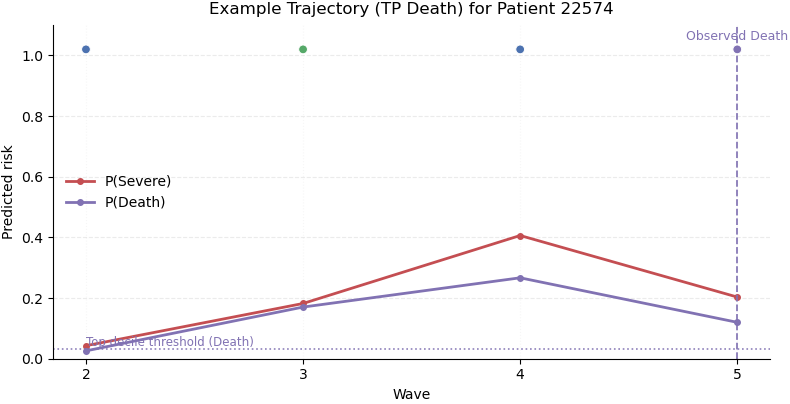

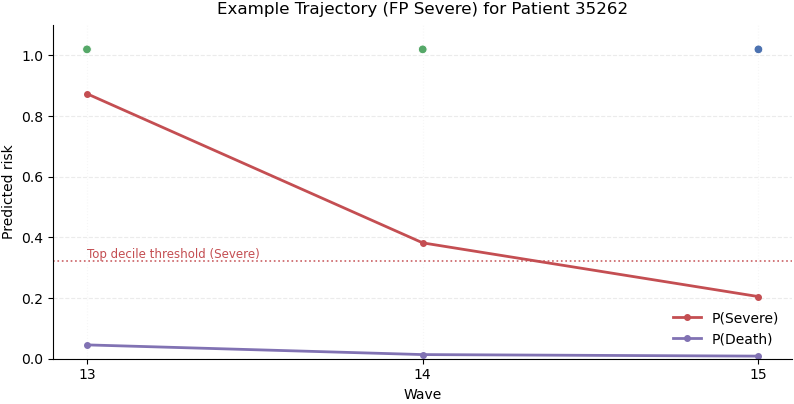

In [7]:
DEA_COLOR = STATE_COLORS["D"]

STATE_SHORT = {0: "H", 1: "M", 2: "S", 3: "D"}
STATE_LABELS = {0: "Healthy", 1: "Mild", 2: "Severe", 3: "Death"}
STATE_SHORT_TO_COLOR = {k: STATE_COLORS[k] for k in ["H", "M", "S", "D"]}

def risk_decile_edges(values, n_bins=10):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    return np.quantile(v, np.linspace(0, 1, n_bins + 1))


def pick_case_patients_fast(df, PID_COL, PS_COL, PD_COL, YTRUE_COL):
    """
    Faster than groupby-apply:
      - compute patient-wise max pS/pD
      - compute whether each patient ever had severe/death
      - select:
         TP Severe: max pS among patients with any severe
         TP Death : max pD among patients with any death
         FP Severe: max pS among patients with no severe
    """
    # patient-wise maxima
    max_pS = df.groupby(PID_COL, sort=False)[PS_COL].max()
    max_pD = df.groupby(PID_COL, sort=False)[PD_COL].max()

    # patient-wise event existence (vectorized)
    had_severe = df[YTRUE_COL].eq(2).groupby(df[PID_COL], sort=False).any()
    had_death  = df[YTRUE_COL].eq(3).groupby(df[PID_COL], sort=False).any()

    # safety: align indices
    had_severe = had_severe.reindex(max_pS.index, fill_value=False)
    had_death  = had_death.reindex(max_pD.index, fill_value=False)

    # pick patients
    tpS_pid = max_pS[had_severe].idxmax() if had_severe.any() else max_pS.idxmax()
    tpD_pid = max_pD[had_death].idxmax()  if had_death.any()  else max_pD.idxmax()
    fpS_pid = max_pS[~had_severe].idxmax() if (~had_severe).any() else max_pS.idxmax()

    return int(tpS_pid), int(tpD_pid), int(fpS_pid)

# plot
def plot_patient_case_paper(
    df, pid,
    PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL,
    outpath=None,
    title_prefix="",
    sev_deciles=None,
    dea_deciles=None,
    endpoint_to_highlight=None,  # "Severe" or "Death" or None
    show_state_letters=False,
):
    
    outpath = Path(outpath)
    g = df.loc[df[PID_COL].eq(pid), [TIME_COL, PS_COL, PD_COL, YTRUE_COL]].sort_values(TIME_COL)
    if g.empty:
        return

    x  = g[TIME_COL].to_numpy()
    pS = g[PS_COL].to_numpy(float)
    pD = g[PD_COL].to_numpy(float)
    y  = g[YTRUE_COL].to_numpy(int)

    fig, ax = plt.subplots(figsize=(8.2, 4.3))

    # main lines
    ax.plot(x, pS, marker="o", lw=2.0, ms=4.0, color=SEV_COLOR, label="P(Severe)")
    ax.plot(x, pD, marker="o", lw=2.0, ms=4.0, color=DEA_COLOR, label="P(Death)")

    # top-decile threshold lines (cleaner than shading)
    if sev_deciles is not None and (endpoint_to_highlight in [None, "Severe"]):
        thrS = float(sev_deciles[-2])
        ax.axhline(thrS, color=SEV_COLOR, ls=":", lw=1.2, alpha=0.9)
        ax.text(x.min(), thrS, "Top decile threshold (Severe)",
                color=SEV_COLOR, fontsize=8.5, va="bottom", ha="left")

    if dea_deciles is not None and (endpoint_to_highlight in [None, "Death"]):
        thrD = float(dea_deciles[-2])
        ax.axhline(thrD, color=DEA_COLOR, ls=":", lw=1.2, alpha=0.9)
        ax.text(x.min(), thrD, "Top decile threshold (Death)",
                color=DEA_COLOR, fontsize=8.5, va="bottom", ha="left")

    # event markers
    idxS = np.flatnonzero(y == 2)
    if idxS.size:
        tS = x[idxS[0]]
        ax.axvline(tS, ls="--", lw=1.3, color=SEV_COLOR, alpha=0.95)
        ax.text(tS, 1.04, "Observed Severe", color=SEV_COLOR,
                ha="center", va="bottom", fontsize=9)

    idxD = np.flatnonzero(y == 3)
    if idxD.size:
        tD = x[idxD[0]]
        ax.axvline(tD, ls="--", lw=1.3, color=DEA_COLOR, alpha=0.95)
        ax.text(tD, 1.04, "Observed Death", color=DEA_COLOR,
                ha="center", va="bottom", fontsize=9)

    # observed state rail (smaller, cleaner)
    y_rail = 1.02
    s_short = np.vectorize(STATE_SHORT.get)(y)
    rail_colors = [STATE_SHORT_TO_COLOR.get(s, "gray") for s in s_short]
    ax.scatter(x, np.full_like(x, y_rail, dtype=float),
               s=40, c=rail_colors, edgecolors="white", linewidths=0.7, zorder=5)

    if show_state_letters:
        for xi, s in zip(x, s_short):
            ax.text(xi, y_rail + 0.02, s, ha="center", va="bottom", fontsize=7.5)

    # axes styling
    ax.set_ylim(0, 1.10)
    ax.set_xlabel("Wave")
    ax.set_ylabel("Predicted risk")
    ax.set_xticks(np.unique(x))
    ax.set_title(f"{title_prefix}Patient {pid}", pad=8)

    ax.legend(frameon=False, loc="best")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.grid(axis="x", linestyle=":", alpha=0.10)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.savefig(outpath.with_suffix(".pdf"), bbox_inches="tight")

    fig.tight_layout()
    if outpath:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def make_case_study_plots(df, OUTDIR, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL):
    # choose patients
    tpS_pid, tpD_pid, fpS_pid = pick_case_patients_fast(df, PID_COL, PS_COL, PD_COL, YTRUE_COL)
    print({"TP_Severe": tpS_pid, "TP_Death": tpD_pid, "FP_Severe": fpS_pid})

    # deciles (computed once for consistent shading across patients)
    sev_dec = risk_decile_edges(df[PS_COL].values, n_bins=10)
    dea_dec = risk_decile_edges(df[PD_COL].values, n_bins=10)

    plot_patient_case_paper(
        df, tpS_pid, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL,
        outpath=os.path.join(OUTDIR, "case_tp_severe.png"),
        title_prefix="Example Trajectory (TP Severe) for ", endpoint_to_highlight="Severe",
         sev_deciles=sev_dec, dea_deciles=dea_dec
    )

    plot_patient_case_paper(
        df, tpD_pid, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL,
        outpath=os.path.join(OUTDIR, "case_tp_death.png"),
        title_prefix="Example Trajectory (TP Death) for ", endpoint_to_highlight="Death",
         sev_deciles=sev_dec, dea_deciles=dea_dec
    )

    plot_patient_case_paper(
        df, fpS_pid, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL,
        outpath=os.path.join(OUTDIR, "case_fp_severe.png"),
        title_prefix="Example Trajectory (FP Severe) for ", endpoint_to_highlight="Severe",
         sev_deciles=sev_dec, dea_deciles=dea_dec
    )

make_case_study_plots(df, OUTDIR, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL)

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd

def patient_level_summary(df, PID_COL, PS_COL, PD_COL, YTRUE_COL):
    max_pS = df.groupby(PID_COL, sort=False)[PS_COL].max()
    max_pD = df.groupby(PID_COL, sort=False)[PD_COL].max()
    had_severe = df[YTRUE_COL].eq(2).groupby(df[PID_COL], sort=False).any()
    had_death  = df[YTRUE_COL].eq(3).groupby(df[PID_COL], sort=False).any()

    s = pd.DataFrame({
        "max_pS": max_pS,
        "max_pD": max_pD,
        "had_severe": had_severe.reindex(max_pS.index, fill_value=False),
        "had_death":  had_death.reindex(max_pD.index, fill_value=False),
    })
    return s

def pick_by_quantile(series, q, higher=True):
    """Pick one PID near a target quantile q (0..1)."""
    s = series.dropna()
    if s.empty:
        return None
    target = s.quantile(q)
    idx = (s - target).abs().idxmin()
    return int(idx)

def pick_cases_for_appendix(df, PID_COL, PS_COL, PD_COL, YTRUE_COL):
    summ = patient_level_summary(df, PID_COL, PS_COL, PD_COL, YTRUE_COL)

    cases = {}

    # ---- Severe endpoint cases ----
    sev_event = summ[summ["had_severe"]]
    sev_none  = summ[~summ["had_severe"]]

    cases["TP_Severe_high"]    = pick_by_quantile(sev_event["max_pS"], 0.95)  # high-risk TP
    cases["TP_Severe_mid"]     = pick_by_quantile(sev_event["max_pS"], 0.70)  # moderate TP
    cases["FN_Severe_lowrisk"] = pick_by_quantile(sev_event["max_pS"], 0.10)  # low-risk but event
    cases["FP_Severe_highrisk"]= pick_by_quantile(sev_none["max_pS"], 0.95)   # high-risk no event
    cases["TN_Severe_low"]     = pick_by_quantile(sev_none["max_pS"], 0.10)   # low-risk no event

    # ---- Death endpoint cases ----
    dea_event = summ[summ["had_death"]]
    dea_none  = summ[~summ["had_death"]]

    cases["TP_Death_high"]     = pick_by_quantile(dea_event["max_pD"], 0.95)
    cases["TP_Death_mid"]      = pick_by_quantile(dea_event["max_pD"], 0.70)
    cases["FN_Death_lowrisk"]  = pick_by_quantile(dea_event["max_pD"], 0.10)
    cases["FP_Death_highrisk"] = pick_by_quantile(dea_none["max_pD"], 0.95)
    cases["TN_Death_low"]      = pick_by_quantile(dea_none["max_pD"], 0.10)

    # drop Nones (if death events are rare etc.)
    cases = {k: v for k, v in cases.items() if v is not None}

    return cases

Appendix cases: {'TP_Severe_high': 37148, 'TP_Severe_mid': 2557, 'FN_Severe_lowrisk': 19522, 'FP_Severe_highrisk': 30527, 'TN_Severe_low': 28854, 'TP_Death_high': 21168, 'TP_Death_mid': 463, 'FN_Death_lowrisk': 6869, 'FP_Death_highrisk': 7629, 'TN_Death_low': 26627}


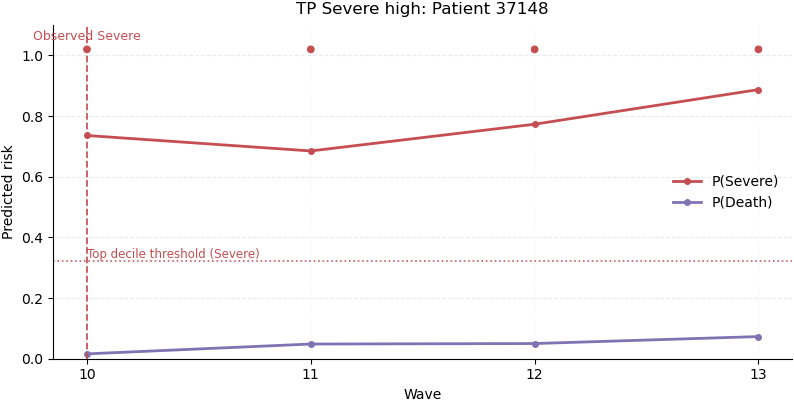

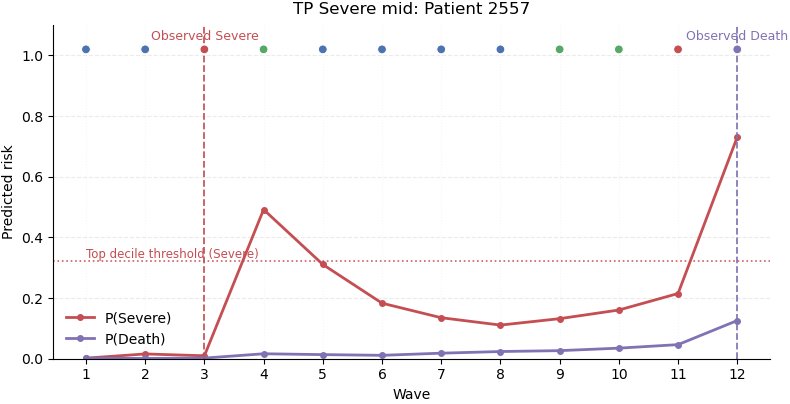

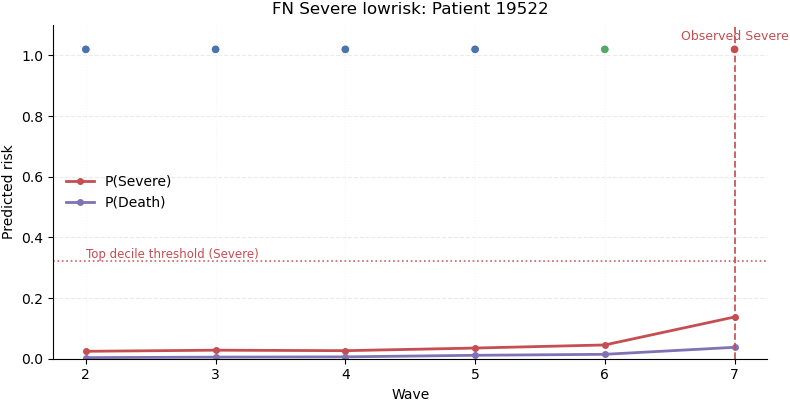

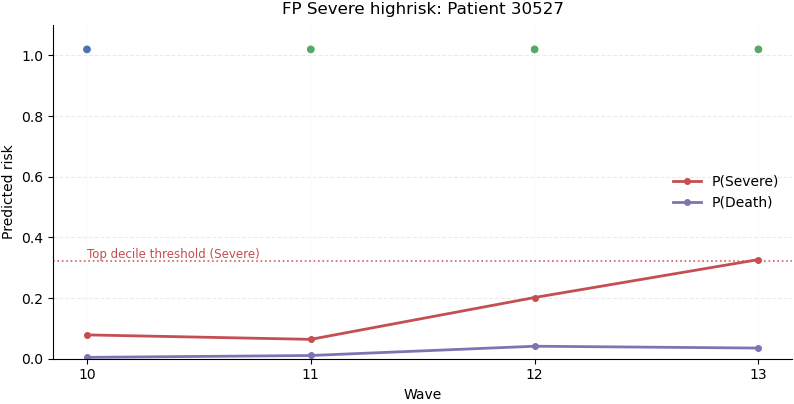

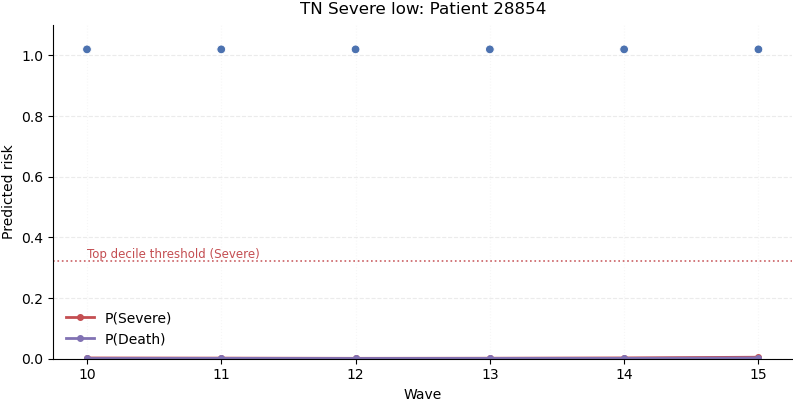

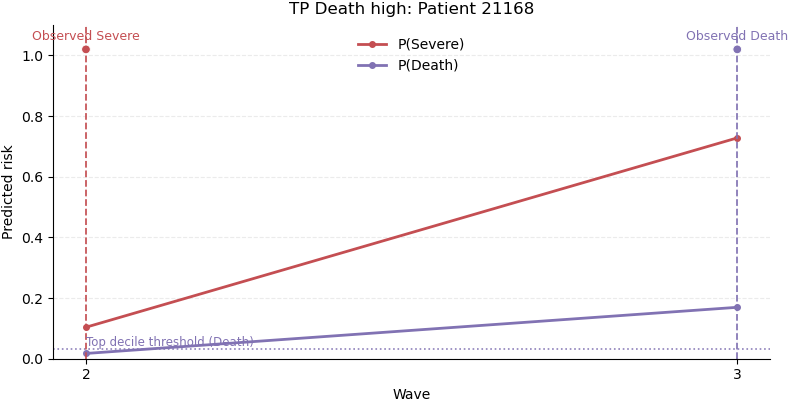

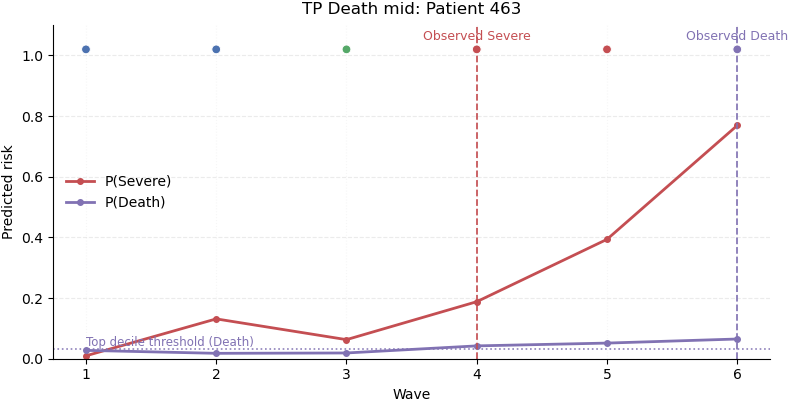

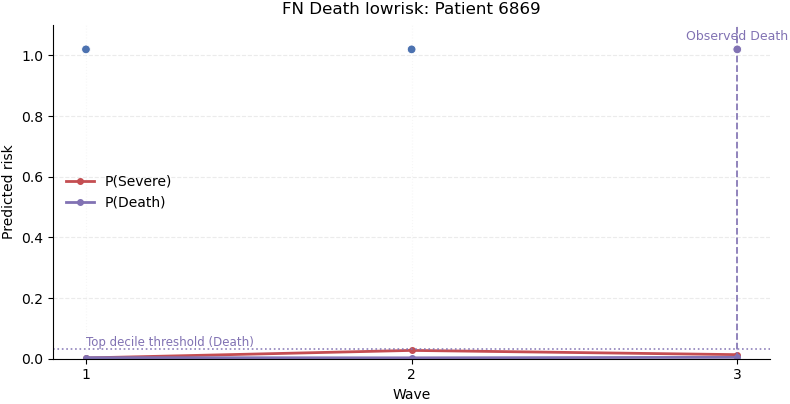

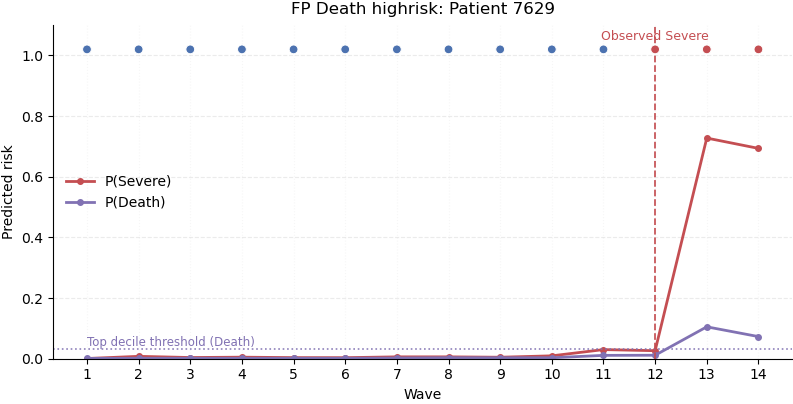

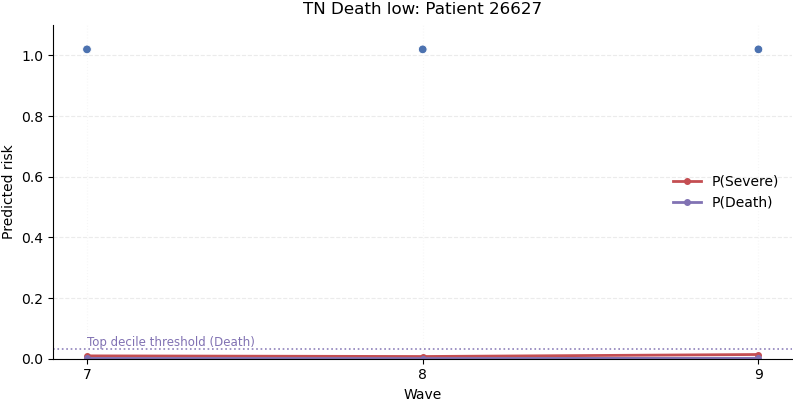

In [9]:
def make_appendix_case_plots(df, OUTDIR, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL):
    OUTDIR = Path(OUTDIR)
    OUTDIR.mkdir(parents=True, exist_ok=True)

    sev_dec = risk_decile_edges(df[PS_COL].values, n_bins=10)
    dea_dec = risk_decile_edges(df[PD_COL].values, n_bins=10)

    cases = pick_cases_for_appendix(df, PID_COL, PS_COL, PD_COL, YTRUE_COL)
    print("Appendix cases:", cases)

    for name, pid in cases.items():
        # choose which endpoint to highlight based on name
        highlight = "Death" if "Death" in name else "Severe"

        plot_patient_case_paper(
            df, pid, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL,
            outpath=str(OUTDIR / f"appendix_{name.lower()}"),  # no suffix needed
            title_prefix=f"{name.replace('_', ' ')}: ",
            endpoint_to_highlight=highlight,
            sev_deciles=sev_dec, dea_deciles=dea_dec
        )

make_appendix_case_plots(df, OUTDIR, PID_COL, TIME_COL, PS_COL, PD_COL, YTRUE_COL)


Attention columns found: ['attn_REGION', 'attn_MARITAL_STATUS', 'attn_RAGENDER', 'attn_RARACEM', 'attn_RAHISPAN', 'attn_RAEDUC']


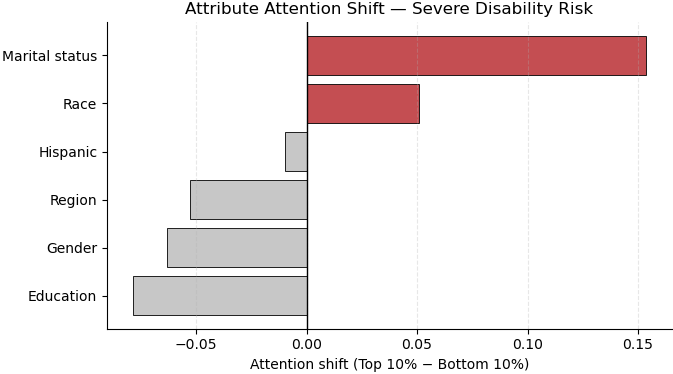

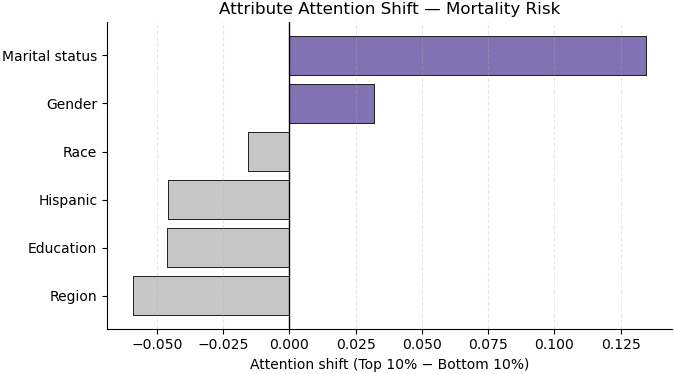


Saved outputs to: post_eval_outputs


In [10]:
# Attribute attention analysis

attn_cols = [c for c in df.columns if c.startswith("attn_")]
print("\nAttention columns found:", attn_cols)

def attention_top_bottom_delta(df, prob_col, attn_cols, out_csv, out_fig, title):
    if not attn_cols:
        print("No attention columns found; skipping:", title)
        return None

    q_hi = df[prob_col].quantile(0.90)
    q_lo = df[prob_col].quantile(0.10)

    hi = df[df[prob_col] >= q_hi]
    lo = df[df[prob_col] <= q_lo]

    summ = pd.DataFrame({
        "attribute": [c.replace("attn_", "") for c in attn_cols],
        "mean_top10": hi[attn_cols].mean().values,
        "mean_bottom10": lo[attn_cols].mean().values,
    })
    summ["delta_top_minus_bottom"] = summ["mean_top10"] - summ["mean_bottom10"]
    summ = summ.sort_values("delta_top_minus_bottom", ascending=False)

    summ.to_csv(out_csv, index=False)

    # plot deltas
    # choose color based on endpoint
    if "Severe" in title:
        main_color = STATE_COLORS["S"]
    elif "Death" in title:
        main_color = STATE_COLORS["D"]
    else:
        main_color = "#333333"

    # Clean labels
    LABELS = {
        "MARITAL_STATUS": "Marital status",
        "RARACEM": "Race",
        "RAHISPAN": "Hispanic",
        "REGION": "Region",
        "RAGENDER": "Gender",
        "RAEDUC": "Education"
    }

    summ["attribute_clean"] = summ["attribute"].map(LABELS)

    # Sort for horizontal plot
    summ = summ.sort_values("delta_top_minus_bottom", ascending=True)

    # Choose state color
    if "Severe" in title:
        main_color = STATE_COLORS["S"]
        clean_title = "Attribute Attention Shift — Severe Disability Risk"
    elif "Death" in title:
        main_color = STATE_COLORS["D"]
        clean_title = "Attribute Attention Shift — Mortality Risk"
    else:
        main_color = "#333333"
        clean_title = title

    plt.figure(figsize=(7, 4))

    # Color by sign but within state palette
    bar_colors = [
        main_color if d > 0 else "#C7C7C7"
        for d in summ["delta_top_minus_bottom"]
    ]

    plt.barh(
        summ["attribute_clean"],
        summ["delta_top_minus_bottom"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6
    )

    plt.axvline(0, color="black", linewidth=1)

    plt.xlabel("Attention shift (Top 10% − Bottom 10%)")
    plt.title(clean_title)

    # Light grid
    plt.grid(axis="x", linestyle="--", alpha=0.3)

    # Remove top/right spines
    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(out_fig, dpi=600, bbox_inches="tight")
    plt.show()

    return summ

attn_S = attention_top_bottom_delta(
    df, PS_COL, attn_cols,
    out_csv=os.path.join(OUTDIR, "attention_summary_severe.csv"),
    out_fig=os.path.join(OUTDIR, "attention_delta_severe.png"),
    title="Attribute attention shift: High vs low Severe risk"
)

attn_D = attention_top_bottom_delta(
    df, PD_COL, attn_cols,
    out_csv=os.path.join(OUTDIR, "attention_summary_death.csv"),
    out_fig=os.path.join(OUTDIR, "attention_delta_death.png"),
    title="Attribute attention shift: High vs low Death risk"
)

print("\nSaved outputs to:", OUTDIR)

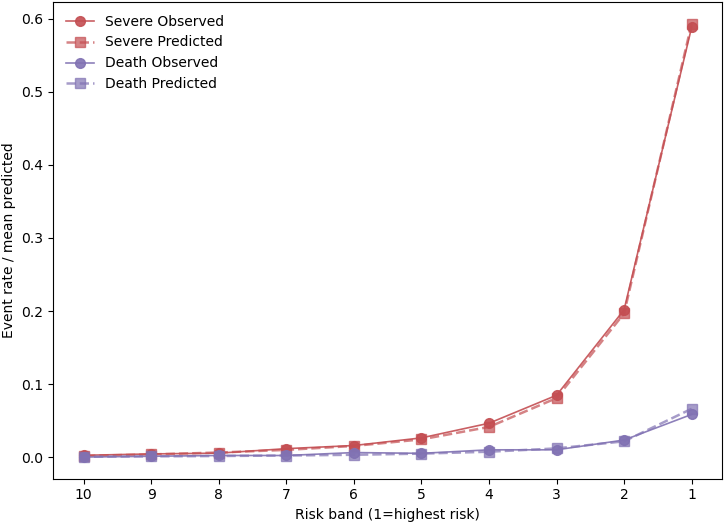

Saved: post_eval_outputs\riskbands_obs_vs_pred_severe_death_clean.pdf
Saved: post_eval_outputs\riskbands_obs_vs_pred_severe_death_clean.png


In [11]:
RUN_DIR = Path(r"C:\Users\manub\OneDrive\Desktop\In_res")
OUT_FIG = Path(OUTDIR) / "riskbands_obs_vs_pred_severe_death_clean.png"

risk_severe = json.load(open(RUN_DIR / "riskbands_severe.json", "r"))
risk_death  = json.load(open(RUN_DIR / "riskbands_death.json", "r"))

bins_S = risk_severe.get("bins", [])
bins_D = risk_death.get("bins", [])

plt.figure(figsize=(7.5, 5.5))
ax = plt.gca()

def _plot_one(bins, color, name):
    x = np.arange(1, len(bins) + 1)
    obs  = [b["event_rate"] for b in bins]
    pred = [b["mean_pred"]  for b in bins]

    # endpoint=color, observed/predicted=linestyle (clean)
    ax.plot(x, obs,  color=color, marker='o', linestyle="-", markersize=7,  linewidth=1.2, alpha=0.9, label=f"{name} Observed")
    ax.plot(x, pred, color=color, marker='s', markersize=7, linestyle="--", linewidth=1.8, alpha=0.7, label=f"{name} Predicted")

if bins_S:
    _plot_one(bins_S, SEV_COLOR, "Severe")
if bins_D:
    _plot_one(bins_D, DEA_COLOR, "Death")

ax.invert_xaxis()
ax.set_xticks(np.arange(1, 11))
ax.set_xlabel("Risk band (1=highest risk)")
ax.set_ylabel("Event rate / mean predicted")
# ax.set_title("Risk bands (deciles): Observed vs Predicted – Severe and Death")
ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(OUT_FIG.with_suffix(".pdf"))        # vector (paper)
plt.savefig(OUT_FIG.with_suffix(".png"), dpi=600)  # high-res raster

plt.show()

print("Saved:", OUT_FIG.with_suffix(".pdf"))
print("Saved:", OUT_FIG.with_suffix(".png"))

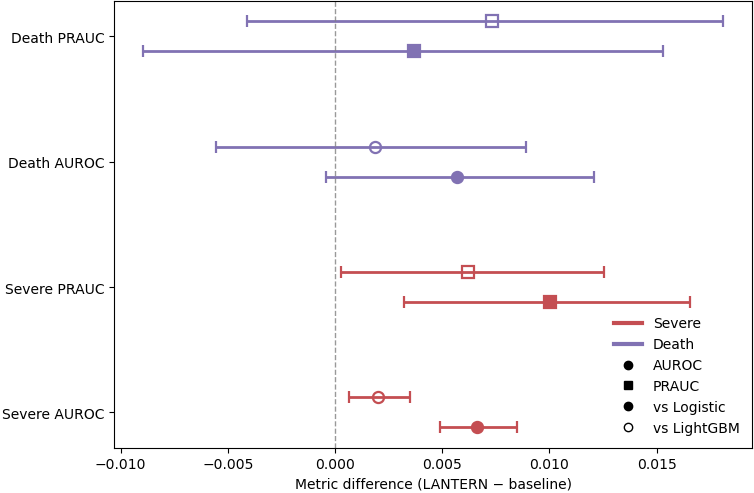

Saved: post_eval_outputs\ci_deltas_vs_baselines_clean.pdf
Saved: post_eval_outputs\ci_deltas_vs_baselines_clean.png


In [12]:
from matplotlib.lines import Line2D

OUT_FIG = Path(OUTDIR) / "ci_deltas_vs_baselines_clean.png"

ci_log  = json.load(open(RUN_DIR / "ci_deltas_vs_logistic.json", "r"))
ci_lgbm = json.load(open(RUN_DIR / "ci_deltas_vs_lightgbm.json", "r"))

items = [
    ("Severe AUROC", "severe_auc", "Severe", SEV_COLOR, "o"),
    ("Severe PRAUC", "severe_pr",  "Severe", SEV_COLOR, "s"),
    ("Death AUROC",  "death_auc",  "Death",  DEA_COLOR, "o"),
    ("Death PRAUC",  "death_pr",   "Death",  DEA_COLOR, "s"),
]

plt.figure(figsize=(7.8, 5.2))
ax = plt.gca()

y = np.arange(len(items))
y_offsets = [-0.12, +0.12]  # logistic, lightgbm

for j, (label, key, endpoint, color, marker) in enumerate(items):
    for i, (baseline_name, ci, filled) in enumerate([
        ("Logistic", ci_log, True),
        ("LightGBM", ci_lgbm, False),
    ]):
        mean = ci[key]["mean_delta"]
        lo   = ci[key]["ci_low"]
        hi   = ci[key]["ci_high"]

        ax.errorbar(
            mean, j + y_offsets[i],
            xerr=[[mean - lo], [hi - mean]],
            fmt=marker,
            color=color, ecolor=color,
            elinewidth=2.0, capsize=4, markersize=8,
            markerfacecolor=(color if filled else "none"),
            markeredgecolor=color, markeredgewidth=1.6,
        )

ax.axvline(0.0, linestyle="--", linewidth=1, color="gray", alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels([x[0] for x in items])
ax.set_xlabel("Metric difference (LANTERN − baseline)")
# ax.set_title("Δ vs baselines (patient bootstrap, 95% CI)")

ax.legend(
    handles=[
        Line2D([0],[0], color=SEV_COLOR, lw=3, label="Severe"),
        Line2D([0],[0], color=DEA_COLOR, lw=3, label="Death"),
        Line2D([0],[0], marker="o", color="black", linestyle="", label="AUROC"),
        Line2D([0],[0], marker="s", color="black", linestyle="", label="PRAUC"),
        Line2D([0],[0], marker="o", color="black", linestyle="", markerfacecolor="black", label="vs Logistic"),
        Line2D([0],[0], marker="o", color="black", linestyle="", markerfacecolor="none",  label="vs LightGBM"),
    ],
    frameon=False,
    loc="lower right",
)

plt.tight_layout()

plt.savefig(OUT_FIG.with_suffix(".pdf"))        # vector (paper)
plt.savefig(OUT_FIG.with_suffix(".png"), dpi=600)  # high-res raster

plt.show()

print("Saved:", OUT_FIG.with_suffix(".pdf"))
print("Saved:", OUT_FIG.with_suffix(".png"))


### Actuarial Projection and Illustrative Example

In [7]:
BASE_DIR = Path(r"/Users/islynnagyepong/Desktop/In_res")

CSV_PATH = BASE_DIR / "Final_Preprocessed_RAND_LTCI_LONG.csv"
SPLIT_PATH = BASE_DIR / "lantern_split.npz"

ID_COL = "HHIDPN"
TIME_COL = "WAVE"
TARGET_COL = "Y_STATE"

# Load split
split_npz = np.load(SPLIT_PATH)

split_pids = {
    "train": split_npz["train"],
    "val": split_npz["val"],
    "test": split_npz["test"],
}

# Load original processed data
df_all = pd.read_csv(CSV_PATH)

df_all = df_all.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df_all[TARGET_COL] = df_all[TARGET_COL].astype(int)

# Recreate patient_idx exactly as in training
df_all["patient_idx"] = df_all[ID_COL].astype("category").cat.codes

# Recreate time
df_all["time"] = df_all[TIME_COL].astype(float)

# Add exact age if available
if "AGE" in df_all.columns:
    df_all["age_time"] = df_all["AGE"].astype(float)

# Select test patients
test_p = split_pids["test"]

df_test = df_all[df_all["patient_idx"].isin(test_p)].copy().reset_index(drop=True)

# Recreate _orig_idx within the test split
df_test["_orig_idx"] = np.arange(len(df_test), dtype=np.int64)

df_test.shape

(37397, 57)

In [8]:
PRED_PATHS = {
    "LogReg": BASE_DIR / "preds_test_log.npz",
    "LightGBM": BASE_DIR / "preds_test_lgbm.npz",
    "GRU": BASE_DIR / "preds_test_gru.npz",
    "LSP": BASE_DIR / "preds_test_lsp.npz",
}

def annotated_from_npz(npz_path, df_test, target_col="Y_STATE"):
    arr = np.load(npz_path)

    y_true = arr["y_true"]
    y_prob = arr["y_prob"]

    assert y_prob.shape[1] == 4
    assert len(df_test) == len(y_true) == y_prob.shape[0]

    # Make sure prediction rows match df_test rows
    if target_col in df_test.columns:
        aligned = np.array_equal(df_test[target_col].to_numpy(dtype=int), y_true.astype(int))
        print(f"{Path(npz_path).name}: aligned with df_test? {aligned}")
        if not aligned:
            raise ValueError(f"{npz_path} is not aligned with df_test.")

    keep_cols = []
    for c in [
        "_orig_idx",
        "patient_idx",
        "time",
        "age_time",
        "AGE",
        "STATE",
        "NEXT_STATE",
        "AGE_GROUP",
    ]:
        if c in df_test.columns:
            keep_cols.append(c)

    out = df_test[keep_cols].copy()

    out["y_true"] = y_true.astype(int)
    out["y_pred"] = y_prob.argmax(axis=1).astype(int)

    out["p_H"] = y_prob[:, 0]
    out["p_M"] = y_prob[:, 1]
    out["p_S"] = y_prob[:, 2]
    out["p_D"] = y_prob[:, 3]

    return out

baseline_dfs = {}

for name, path in PRED_PATHS.items():
    baseline_dfs[name] = annotated_from_npz(path, df_test)
    print(name, baseline_dfs[name].shape)

lantern_df = df.copy()

model_dfs = {
    "LANTERN": lantern_df,
    **baseline_dfs,
}

model_dfs.keys()

preds_test_log.npz: aligned with df_test? True
LogReg (37397, 14)
preds_test_lgbm.npz: aligned with df_test? True
LightGBM (37397, 14)
preds_test_gru.npz: aligned with df_test? True
GRU (37397, 14)
preds_test_lsp.npz: aligned with df_test? True
LSP (37397, 14)


dict_keys(['LANTERN', 'LogReg', 'LightGBM', 'GRU', 'LSP'])

In [9]:
STATE_NAMES = ["Healthy", "Mild", "Severe", "Death"]
PROB_COLS = ["p_H", "p_M", "p_S", "p_D"]

STATE_MAP = {
    "H": 0,
    "M": 1,
    "S": 2,
    "D": 3,
    0: 0,
    1: 1,
    2: 2,
    3: 3,
}

AGE_GROUP_ORDER = ["30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-100"]

In [10]:
def estimate_transition_matrices_by_agegroup(
    df_model,
    age_group_col="AGE_GROUP",
    state_col="STATE",
    prob_cols=PROB_COLS,
    age_group_order=None,
):
    df_model = df_model.copy()
    df_model["current_state_id"] = df_model[state_col].map(STATE_MAP)

    if df_model["current_state_id"].isna().any():
        bad = df_model.loc[df_model["current_state_id"].isna(), state_col].unique()
        raise ValueError(f"Unmapped current states found: {bad}")

    if age_group_order is None:
        age_group_order = sorted(df_model[age_group_col].dropna().unique())

    matrices = {}

    for age_group in age_group_order:
        g_age = df_model[df_model[age_group_col] == age_group]

        P = np.zeros((4, 4), dtype=float)

        for r in range(4):
            g_r = g_age[g_age["current_state_id"] == r]

            if len(g_r) == 0:
                P[r, :] = np.nan
            else:
                P[r, :] = g_r[list(prob_cols)].mean().to_numpy(dtype=float)

        # Death absorbing
        P[3, :] = np.array([0.0, 0.0, 0.0, 1.0])

        # Normalize non-death rows
        for r in range(3):
            if np.all(np.isfinite(P[r, :])):
                row_sum = P[r, :].sum()
                if row_sum > 0:
                    P[r, :] = P[r, :] / row_sum

        matrices[age_group] = P

    return matrices

In [11]:
def project_cohort_agegroups(
    matrices,
    age_group_order,
    start_group="60-69",
    start_dist=np.array([1.0, 0.0, 0.0, 0.0]),
):
    start_idx = age_group_order.index(start_group)
    pi = np.asarray(start_dist, dtype=float)

    rows = []

    for j in range(start_idx, len(age_group_order)):
        group = age_group_order[j]

        rows.append({
            "AGE_GROUP": group,
            "Healthy": pi[0],
            "Mild": pi[1],
            "Severe": pi[2],
            "Death": pi[3],
            "Disabled": pi[1] + pi[2],
            "Alive": pi[0] + pi[1] + pi[2],
        })

        if j < len(age_group_order) - 1:
            P = matrices[group]

            if np.any(~np.isfinite(P)):
                raise ValueError(f"Transition matrix for {group} contains NaNs.")

            pi = pi @ P

    return pd.DataFrame(rows)

In [12]:
def compute_group_step_epv(
    projection_df,
    annual_discount_rate=0.03,
    years_per_group=10,
    benefit_H=0.0,
    benefit_M=10_000.0,
    benefit_S=50_000.0,
    benefit_D=0.0,
):
    v_group = (1 / (1 + annual_discount_rate)) ** years_per_group
    benefits = np.array([benefit_H, benefit_M, benefit_S, benefit_D], dtype=float)

    epv = 0.0
    rows = []

    for t, row in projection_df.reset_index(drop=True).iterrows():
        pi = np.array([
            row["Healthy"],
            row["Mild"],
            row["Severe"],
            row["Death"],
        ])

        expected_benefit = float(pi @ benefits)
        discount_factor = v_group ** t
        discounted_expected_benefit = discount_factor * expected_benefit

        rows.append({
            "step": t,
            "AGE_GROUP": row["AGE_GROUP"],
            "expected_benefit": expected_benefit,
            "discount_factor": discount_factor,
            "discounted_expected_benefit": discounted_expected_benefit,
        })

        epv += discounted_expected_benefit

    return epv, pd.DataFrame(rows)

In [13]:
def actuarial_summary_for_model(
    name,
    df_model,
    age_group_order,
    start_group="60-69",
    annual_discount_rate=0.03,
    years_per_group=10,
    benefit_M=10_000,
    benefit_S=50_000,
):
    matrices = estimate_transition_matrices_by_agegroup(
        df_model,
        age_group_col="AGE_GROUP",
        state_col="STATE",
        age_group_order=age_group_order,
    )

    projection = project_cohort_agegroups(
        matrices,
        age_group_order,
        start_group=start_group,
        start_dist=np.array([1, 0, 0, 0]),
    )

    epv, epv_detail = compute_group_step_epv(
        projection,
        annual_discount_rate=annual_discount_rate,
        years_per_group=years_per_group,
        benefit_M=benefit_M,
        benefit_S=benefit_S,
    )

    summary = {
        "Model": name,
        "EPV": epv,
        "Severe_final": float(projection["Severe"].iloc[-1]),
        "Death_final": float(projection["Death"].iloc[-1]),
        "Disabled_final": float(projection["Disabled"].iloc[-1]),
        "Expected_severe_group_steps": float(projection["Severe"].sum()),
        "Expected_disabled_group_steps": float(projection["Disabled"].sum()),
    }

    return matrices, projection, epv_detail, summary

In [14]:
results = {}
summaries = []

for name, df_model in model_dfs.items():
    matrices, projection, epv_detail, summary = actuarial_summary_for_model(
        name,
        df_model,
        AGE_GROUP_ORDER,
        start_group="60-69",
        annual_discount_rate=0.03,
        years_per_group=10,
        benefit_M=10_000,
        benefit_S=50_000,
    )

    results[name] = {
        "matrices": matrices,
        "projection": projection,
        "epv_detail": epv_detail,
    }

    summaries.append(summary)

epv_summary = pd.DataFrame(summaries)
epv_summary

,Model,EPV,Severe_final,Death_final,Disabled_final,Expected_severe_group_steps,Expected_disabled_group_steps
0,LANTERN,8003.151836,0.143528,0.052121,0.366791,0.234858,0.677450
1,LogReg,8809.900423,0.149983,0.050626,0.359081,0.260079,0.713895
2,LightGBM,7871.170171,0.144126,0.048328,0.367440,0.232414,0.667259
3,GRU,9531.992106,0.149222,0.053783,0.370703,0.280626,0.740155
4,LSP,1529.832431,0.023545,0.003023,0.053726,0.047405,0.109220


In [15]:
MODEL_STYLES = {
    "LANTERN":   {"color": "#dd1c77", "linestyle": "-", "linewidth": 2.1, "zorder": 5},
    "Logistic":  {"color": "#1f3a93", "linestyle": "-", "linewidth": 1.8, "zorder": 3},
    "LightGBM":  {"color": "#2ca25f", "linestyle": "-", "linewidth": 1.8, "zorder": 4},
    "GRU":       {"color": "#f1c40f", "linestyle": "-", "linewidth": 1.8, "zorder": 3},
    "Heuristic": {"color": "#00cfe3", "linestyle": "-", "linewidth": 1.8, "zorder": 2},
}

MODEL_LABEL_MAP = {
    "LANTERN": "LANTERN",
    "LogReg": "Logistic",
    "Logistic": "Logistic",
    "LightGBM": "LightGBM",
    "GRU": "GRU",
    "LSP": "Heuristic",
    "Heuristic": "Heuristic",
}

def get_style(model_name):
    label = MODEL_LABEL_MAP.get(model_name, model_name)
    return MODEL_STYLES.get(
        label,
        {"color": "black", "linestyle": "-", "linewidth": 1.9, "zorder": 2}
    )

def plot_projection_state_paper(
    results,
    state,
    ylabel=None,
    title=None,
    filename=None,
    model_order=("LANTERN", "LogReg", "LightGBM", "GRU", "LSP"),
):
    plt.figure(figsize=(6.4, 4.2))
    ax = plt.gca()

    for model_name in model_order:
        if model_name not in results:
            continue

        proj = results[model_name]["projection"]
        label = MODEL_LABEL_MAP.get(model_name, model_name)
        style = get_style(model_name)

        ax.plot(
            proj["AGE_GROUP"],
            proj[state],
            marker="o",
            markersize=4.5,
            label=label,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            zorder=style["zorder"],
        )

    ax.set_xlabel("Age Group", labelpad=12)
    ax.set_ylabel(ylabel or "Projected Occupancy Probability", labelpad=12)
    # ax.set_title(title or f"Projected {state} occupancy")
    ax.legend(frameon=False)

    plt.tight_layout()

    if filename is None:
        filename = f"projected_{state.lower()}_occupancy"

    out_base = Path(OUTDIR) / filename

    plt.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    plt.savefig(out_base.with_suffix(".png"), dpi=600, bbox_inches="tight")
    plt.show()

    print("Saved:", out_base.with_suffix(".pdf"))
    print("Saved:", out_base.with_suffix(".png"))

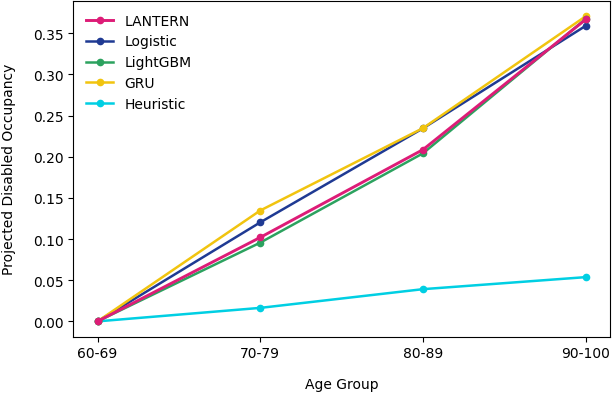

Saved: post_eval_outputs/projected_disabled_occupancy.pdf
Saved: post_eval_outputs/projected_disabled_occupancy.png


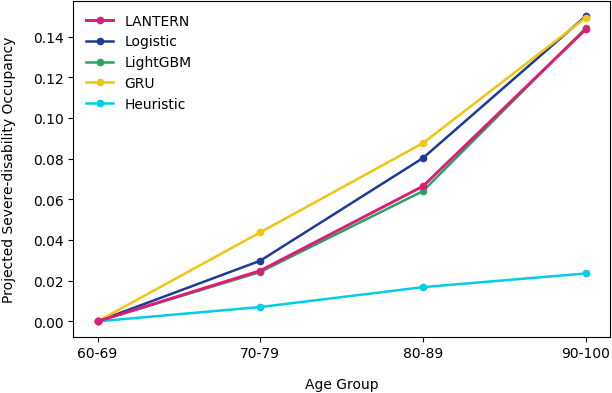

Saved: post_eval_outputs/projected_severe_occupancy.pdf
Saved: post_eval_outputs/projected_severe_occupancy.png


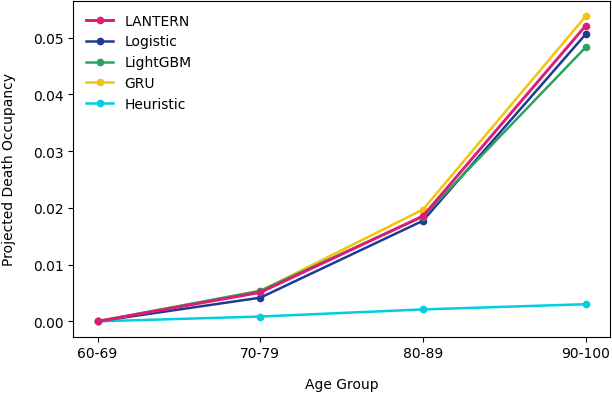

Saved: post_eval_outputs/projected_death_occupancy.pdf
Saved: post_eval_outputs/projected_death_occupancy.png


In [16]:
plot_projection_state_paper(
    results,
    state="Disabled",
    ylabel="Projected Disabled Occupancy",
    title="Projected Disabled Occupancy",
    filename="projected_disabled_occupancy",
)

plot_projection_state_paper(
    results,
    state="Severe",
    ylabel="Projected Severe-disability Occupancy",
    title="Projected Severe Disability Occupancy",
    filename="projected_severe_occupancy",
)

plot_projection_state_paper(
    results,
    state="Death",
    ylabel="Projected Death Occupancy",
    title="Projected Death Occupancy",
    filename="projected_death_occupancy",
)

In [17]:
def observed_transition_matrices_by_agegroup(
    df_model,
    age_group_order,
    age_group_col="AGE_GROUP",
    state_col="STATE",
    next_state_col="y_true",
):
    tmp = df_model.copy()
    tmp["current_state_id"] = tmp[state_col].map(STATE_MAP)

    observed = {}

    for age_group in age_group_order:
        g = tmp[tmp[age_group_col] == age_group]

        obs = pd.crosstab(
            g["current_state_id"],
            g[next_state_col],
            normalize="index"
        )

        obs = obs.reindex(index=[0, 1, 2, 3], columns=[0, 1, 2, 3], fill_value=0.0)
        obs.loc[3, :] = [0, 0, 0, 1]

        observed[age_group] = obs.to_numpy(dtype=float)

    return observed


def transition_matrix_errors(pred_matrices, obs_matrices):
    maes = []
    rmses = []

    for age_group, P_pred in pred_matrices.items():
        P_obs = obs_matrices[age_group]

        mask = np.isfinite(P_pred) & np.isfinite(P_obs)

        maes.append(np.mean(np.abs(P_pred[mask] - P_obs[mask])))
        rmses.append(np.sqrt(np.mean((P_pred[mask] - P_obs[mask]) ** 2)))

    return {
        "Matrix_MAE": float(np.mean(maes)),
        "Matrix_RMSE": float(np.mean(rmses)),
    }

In [18]:
matrix_error_rows = []

# Observed transitions are the same for all models, so use LANTERN or LogReg df
obs_matrices = observed_transition_matrices_by_agegroup(
    model_dfs["LANTERN"],
    AGE_GROUP_ORDER
)

for name, obj in results.items():
    errs = transition_matrix_errors(obj["matrices"], obs_matrices)
    errs["Model"] = name
    matrix_error_rows.append(errs)

matrix_error_summary = pd.DataFrame(matrix_error_rows)
matrix_error_summary

,Matrix_MAE,Matrix_RMSE,Model
0,0.019825,0.035630,LANTERN
1,0.031617,0.055264,LogReg
2,0.022399,0.039684,LightGBM
3,0.065630,0.106306,GRU
4,0.112801,0.183056,LSP


In [19]:
final_app_summary = epv_summary.merge(matrix_error_summary, on="Model")

final_app_summary = final_app_summary[
    [
        "Model",
        "Matrix_MAE",
        "Matrix_RMSE",
        "EPV",
        "Severe_final",
        "Death_final",
        "Disabled_final",
        "Expected_severe_group_steps",
        "Expected_disabled_group_steps",
    ]
]

final_app_summary

,Model,Matrix_MAE,Matrix_RMSE,EPV,Severe_final,Death_final,Disabled_final,Expected_severe_group_steps,Expected_disabled_group_steps
0,LANTERN,0.019825,0.035630,8003.151836,0.143528,0.052121,0.366791,0.234858,0.677450
1,LogReg,0.031617,0.055264,8809.900423,0.149983,0.050626,0.359081,0.260079,0.713895
2,LightGBM,0.022399,0.039684,7871.170171,0.144126,0.048328,0.367440,0.232414,0.667259
3,GRU,0.065630,0.106306,9531.992106,0.149222,0.053783,0.370703,0.280626,0.740155
4,LSP,0.112801,0.183056,1529.832431,0.023545,0.003023,0.053726,0.047405,0.109220
